C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6860\834634078.py:79: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.




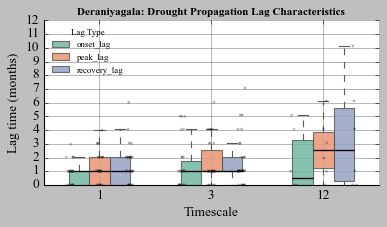

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6860\834634078.py:79: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.




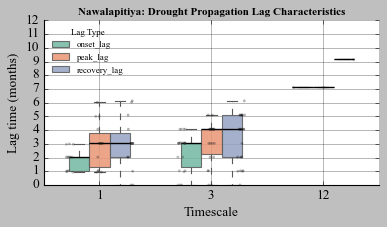

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6860\834634078.py:79: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.




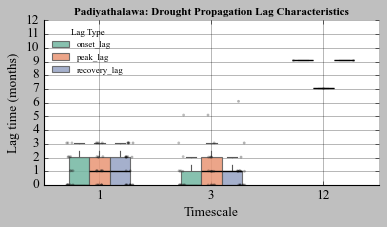

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_6860\834634078.py:79: FutureWarning:



Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:k'` for the same effect.




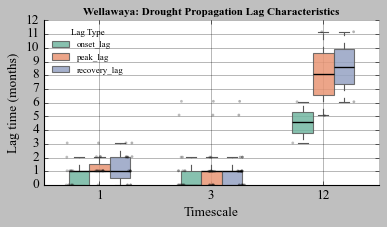

All basin plots saved successfully.


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os
import numpy as np

# ------------------------------------------------------------------
# GLOBAL STYLE
# ------------------------------------------------------------------
plt.style.use('classic')
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 12

# ------------------------------------------------------------------
# FILE PATHS
# ------------------------------------------------------------------
file_path = r"D:\Research Datasets\Additional Datasets\Working Folder\Four basins\ICESWSE_Results\Detailed_Drought_Analysis\Detailed_Propagation_Results.xlsx"
sheet_name = "Paired_Events"

output_dir = r"D:\Research Datasets\Additional Datasets\Working Folder\Four basins\ICESWSE_Results\Detailed_Drought_Analysis\Plots"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------------------------------
# READ DATA
# ------------------------------------------------------------------
df = pd.read_excel(file_path, sheet_name=sheet_name)

basins = df['basin'].unique()
lag_columns = ['onset_lag', 'peak_lag', 'recovery_lag']

# ------------------------------------------------------------------
# RESHAPE DATA
# ------------------------------------------------------------------
df_melt = pd.melt(
    df,
    id_vars=['basin', 'timescale', 'threshold'],
    value_vars=lag_columns,
    var_name='Lag Type',
    value_name='Lag Value'
)

# ------------------------------------------------------------------
# Y-AXIS SETTINGS
# ------------------------------------------------------------------
y_max = int(np.ceil(df_melt['Lag Value'].max()))
y_ticks = np.arange(0, y_max + 1, 1)

# ------------------------------------------------------------------
# PLOTTING
# ------------------------------------------------------------------
for basin in basins:

    df_basin = df_melt[df_melt['basin'] == basin]

    fig, ax = plt.subplots(figsize=(5, 3))

    # Ensure grid is below data
    ax.set_axisbelow(True)

    # ---------------- BOX PLOT ----------------
    sns.boxplot(
        data=df_basin,
        x='timescale',
        y='Lag Value',
        hue='Lag Type',
        palette='Set2',
        width=0.55,
        linewidth=1.0,
        fliersize=0,
        boxprops=dict(alpha=0.85),
        medianprops=dict(color='black', linewidth=1.2),
        whiskerprops=dict(linewidth=1.0),
        capprops=dict(linewidth=1.0),
        ax=ax
    )

    # ---------------- STRIP PLOT ----------------
    sns.stripplot(
        data=df_basin,
        x='timescale',
        y='Lag Value',
        hue='Lag Type',
        dodge=True,
        color='k',
        alpha=0.3,
        size=2.5,
        legend=False,
        ax=ax
    )

    # ---------------- AXES & LABELS ----------------
    ax.set_title(
        f'{basin}: Drought Propagation Lag Characteristics',
        fontsize=10,
        fontweight='bold'
    )

    ax.set_xlabel('Timescale', fontsize=12)
    ax.set_ylabel('Lag time (months)', fontsize=12)

    ax.set_ylim(0, y_max)
    ax.set_yticks(y_ticks)

    # Grid only on Y-axis, behind data
    ax.grid(True, axis='both', linestyle='-', linewidth=0.5, alpha=0.5)

    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Legend (remove duplicates from stripplot)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles[:3],
        labels[:3],
        title='Lag Type',
        fontsize=8,
        title_fontsize=8,
        loc='upper left',
        frameon=False,ncol=1
    )

    # ---------------- SAVE ----------------
    output_path = os.path.join(
        output_dir,
        f"{basin}_Drought_Propagation_Lags.png"
    )

    plt.tight_layout()
    plt.savefig(output_path, dpi=300)
    plt.show()

print("All basin plots saved successfully.")
